<a href="https://colab.research.google.com/github/nabillahumi/S5-Mesin_Learning/blob/main/Kuis_01/K_Means_Euclide.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Means Euclide

In [1]:
import numpy as np

class CustomKMeans:
    def __init__(self, n_clusters=4, max_iter=300, tol=1e-4, metric='euclidean', random_state=None):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.metric = metric
        self.random_state = random_state
        self.cluster_centers_ = None
        self.labels_ = None
        self.inertia_ = None

    def _calculate_distances(self, X, centers):
        """
        Menghitung jarak antara setiap titik di X dengan setiap centroid.
        Secara dinamis meneruskan L1 atau L2 norm (ord=1 atau ord=2) untuk Manhattan/Euclidean.
        """
        distances = np.zeros((X.shape[0], self.n_clusters))

        # 1. Tentukan argumen norm dinamis (l=1 untuk Manhattan, l=2 untuk Euclidean)
        if self.metric == 'euclidean':
            l_norm = 2
        elif self.metric == 'manhattan':
            l_norm = 1

        for i, center in enumerate(centers):
            if self.metric in ['euclidean', 'manhattan']:
                # np.linalg.norm akan otomatis mengalikan L1/L2 sesuai input ord
                distances[:, i] = np.linalg.norm(X - center, ord=l_norm, axis=1)

            elif self.metric == 'cosine':
                # d(x,y) = 1 - (sum(x_i * y_i) / (sqrt(sum(x_i^2)) * sqrt(sum(y_i^2))))
                eps = 1e-10

                # Panjang vektor selalu dihitung menggunakan L2 norm (ord=2)
                norm_X = np.linalg.norm(X, ord=2, axis=1) + eps
                norm_center = np.linalg.norm(center, ord=2) + eps
                dot_product = np.sum(X * center, axis=1)

                cosine_sim = dot_product / (norm_X * norm_center)
                distances[:, i] = 1 - cosine_sim

            else:
                raise ValueError(f"Unknown metric: {self.metric}. Use 'euclidean', 'manhattan', or 'cosine'.")

        return distances

    def fit(self, X):
        # Set random seed untuk hasil yang konsisten
        if self.random_state is not None:
            np.random.seed(self.random_state)

        n_samples, n_features = X.shape

        # Inisialisasi centroid secara acak (memilih titik acak dari data)
        random_indices = np.random.choice(n_samples, self.n_clusters, replace=False)
        self.cluster_centers_ = X[random_indices].copy()

        for iteration in range(self.max_iter):
            old_centers = self.cluster_centers_.copy()

            # Langkah 1: Assignment - Hitung jarak dan tentukan klaster terdekat
            # Ini memanggil fungsi jarak dinamis yang baru saja diperbaiki
            distances = self._calculate_distances(X, self.cluster_centers_)
            self.labels_ = np.argmin(distances, axis=1)

            # Langkah 2: Update - Hitung centroid baru berdasarkan rata-rata titik di setiap klaster
            for k in range(self.n_clusters):
                cluster_points = X[self.labels_ == k]
                if len(cluster_points) > 0:
                    self.cluster_centers_[k] = np.mean(cluster_points, axis=0)

            # Cek konvergensi
            center_shift = np.sum((self.cluster_centers_ - old_centers) ** 2)
            if center_shift < self.tol:
                break

        # Hitung inertia (SSE) untuk model final
        # (inertia standar menggunakan sum of squared distances / L2)
        if self.metric in ['euclidean', 'manhattan']:
            final_distances = self._calculate_distances(X, self.cluster_centers_)
            self.inertia_ = np.sum([np.sum((X[self.labels_ == k] - self.cluster_centers_[k]) ** 2) for k in range(self.n_clusters)])

        return self

    def fit_predict(self, X):
        self.fit(X)
        return self.labels_

In [2]:
import time
import tracemalloc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# BAGIAN A: LOAD DATA & PREPROCESSING

df = pd.read_csv('marketing_campaign.csv', sep='\t')

# Pilih fitur numerik yang relevan
kolom_fitur = [
    'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency',
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
    'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'NumWebVisitsMonth'
]
kolom_ada = [k for k in kolom_fitur if k in df.columns]
df_fitur  = df[kolom_ada].dropna()

# Encoding jika ada kolom teks
kolom_teks = df_fitur.select_dtypes(include='object').columns.tolist()
if kolom_teks:
    df_fitur = pd.get_dummies(df_fitur, columns=kolom_teks, drop_first=True)

# Standardisasi
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_fitur)

# L2 Normalization untuk Cosine (tidak dipakai di sini, tapi disiapkan)
from sklearn.preprocessing import Normalizer
X_l2 = Normalizer(norm='l2').fit_transform(X_scaled)

print(f"Data siap | Shape: {X_scaled.shape} | Baris: {len(df_fitur)}")

Data siap | Shape: (2216, 16) | Baris: 2216


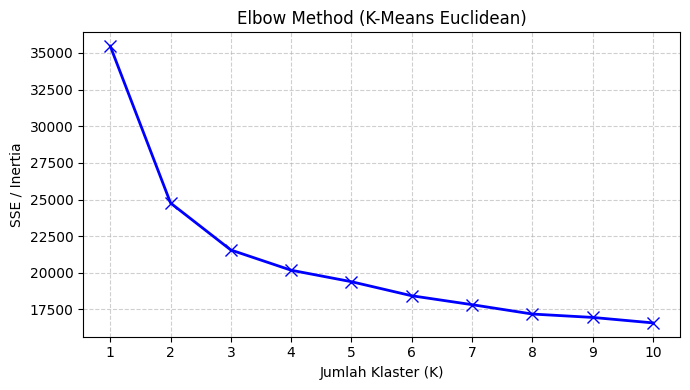

In [3]:
# BAGIAN B: ELBOW METHOD (untuk menentukan K terbaik)

K_range = range(1, 11)
sse     = []

for k in K_range:
    km = CustomKMeans(n_clusters=k, random_state=42, metric='euclidean')
    km.fit(X_scaled)
    sse.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(K_range), sse, 'bx-', linewidth=2, markersize=8)
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('SSE / Inertia')
plt.title('Elbow Method (K-Means Euclidean)')
plt.xticks(list(K_range))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('a1_elbow.png')
plt.show()

K_TERBAIK = 4  # Ganti sesuai hasil elbow

In [4]:
# BAGIAN C: K-MEANS EUCLIDEAN — Latih + Ukur Performa

print("\n" + "="*52)
print("  K-MEANS — METRIK: EUCLIDEAN")
print("="*52)

# Mulai ukur memori dan waktu
tracemalloc.start()
t_mulai = time.time()

# Latih K-Means (Euclidean adalah default sklearn)
km_euclid  = CustomKMeans(n_clusters=K_TERBAIK, random_state=42, metric='euclidean')
lbl_euclid = km_euclid.fit_predict(X_scaled)

# Hentikan ukur
t_selesai = time.time()
_, mem_puncak = tracemalloc.get_traced_memory()
tracemalloc.stop()

# Silhouette Score
sil_euclid = silhouette_score(X_scaled, lbl_euclid, metric='euclidean')

# Tampilkan Evaluasi
print(f"  Jumlah Klaster    : {K_TERBAIK}")
print(f"  Waktu Eksekusi    : {t_selesai - t_mulai:.4f} detik")
print(f"  Memori Puncak     : {mem_puncak/1024:.2f} KB ({mem_puncak/1024**2:.4f} MB)")
print(f"  Silhouette Score  : {sil_euclid:.4f}")
print("="*52)


  K-MEANS — METRIK: EUCLIDEAN
  Jumlah Klaster    : 4
  Waktu Eksekusi    : 0.0151 detik
  Memori Puncak     : 887.90 KB (0.8671 MB)
  Silhouette Score  : 0.1640


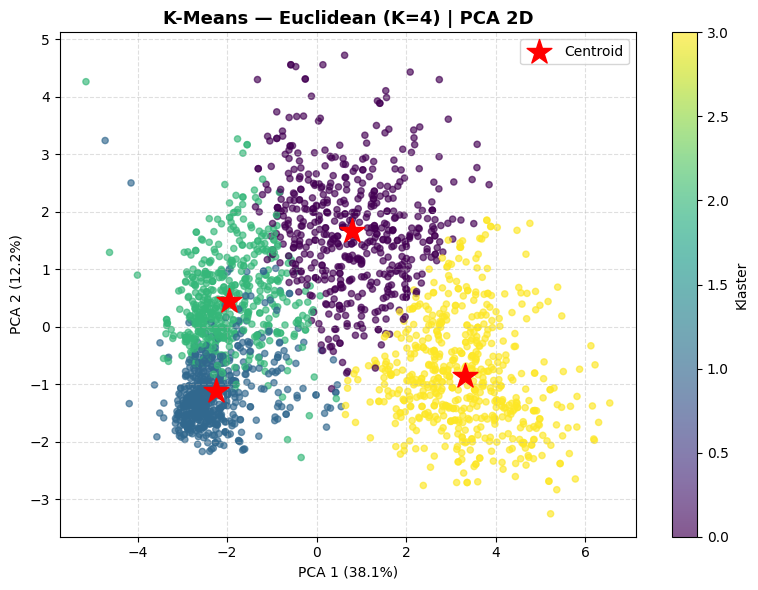

Visualisasi disimpan: 'a1_kmeans_plot.png'


In [5]:
# BAGIAN D: VISUALISASI PCA (Euclidean)

pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
v1, v2 = pca.explained_variance_ratio_ * 100

# Mengubah menjadi 1 subplot tunggal dengan ukuran proporsional
fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))

# Plot Euclidean
sc1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=lbl_euclid,
                  cmap='viridis', s=20, alpha=0.65)
cen1 = pca.transform(km_euclid.cluster_centers_)
ax1.scatter(cen1[:, 0], cen1[:, 1], c='red', marker='*', s=350, zorder=5, label='Centroid')

# Menggabungkan judul utama ke dalam title ax1
ax1.set_title(f'K-Means — Euclidean (K={K_TERBAIK}) | PCA 2D', fontsize=13, fontweight='bold')
ax1.set_xlabel(f'PCA 1 ({v1:.1f}%)')
ax1.set_ylabel(f'PCA 2 ({v2:.1f}%)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.4)
plt.colorbar(sc1, ax=ax1, label='Klaster')

plt.tight_layout()
plt.savefig('a1_kmeans_plot.png', dpi=150)
plt.show()
print("Visualisasi disimpan: 'a1_kmeans_plot.png'")